In [38]:
from nilearn.image import resample_img
import nibabel as nib

In [39]:
from pathlib import Path
path = Path("../nsdata/betas/subj01/betas_session01.nii.gz").resolve()
path.exists()

True

In [40]:
from nilearn.datasets import load_mni152_template

# Load the MNI template (default: 2mm resolution)
mni_template = load_mni152_template(resolution=2)
mni_affine = mni_template.affine  # Target affine (4x4 matrix)
mni_shape = mni_template.shape    # Target shape (3D dimensions)
mni_shape

(99, 117, 95)

In [41]:
img = nib.load(path).slicer[..., 5]
img

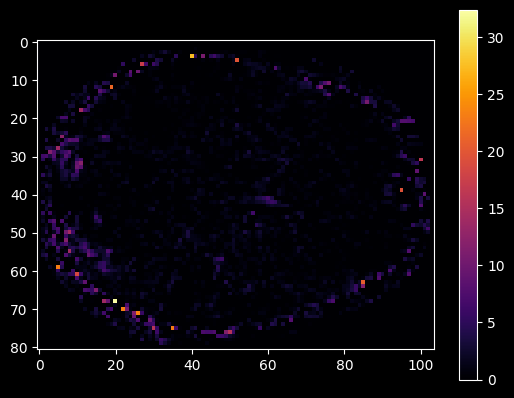

In [50]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("dark_background")
new_img = nib.nifti1.Nifti1Image(img.get_fdata(dtype=np.float32)/300., affine=img.affine)
plt.imshow(new_img.get_fdata()[:, :, 50], vmin=0, cmap="inferno")
plt.colorbar()

In [51]:
# Resample beta map to MNI space
beta_mni = resample_img(
    img=img,        # Your subject-native beta map
    target_affine=mni_affine,        # MNI template affine
    target_shape=mni_shape,          # MNI template shape (optional but recommended)
    interpolation='continuous',      # Cubic interpolation (matches NSD's method)
    fill_value=0,                    # Set non-brain voxels to 0 (like NSD)
    clip=True                        # Clip values outside original range
)

/var/folders/lr/70kn5pjn69bdqbrtq53m3nch0000gn/T/ipykernel_24186/1224077522.py:2: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  beta_mni = resample_img(
/var/folders/lr/70kn5pjn69bdqbrtq53m3nch0000gn/T/ipykernel_24186/1224077522.py:2: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  beta_mni = resample_img(
/var/folders/lr/70kn5pjn69bdqbrtq53m3nch0000gn/T/ipykernel_24186/1224077522.py:2: UserWarning: Casting data from int16 to float32
  beta_mni = resample_img(


In [52]:
d = beta_mni.get_fdata(dtype=np.float32)/300
d.shape

(99, 117, 95)

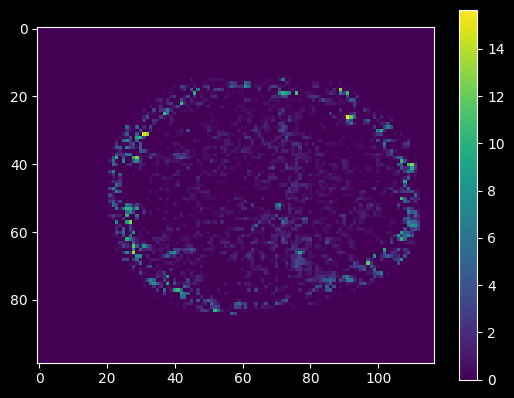

In [53]:
plt.imshow(d[:, :, 95//2], vmin=0)
plt.colorbar()

/var/folders/lr/70kn5pjn69bdqbrtq53m3nch0000gn/T/ipykernel_24186/246339147.py:1: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  new_beta_mni = resample_img(
/var/folders/lr/70kn5pjn69bdqbrtq53m3nch0000gn/T/ipykernel_24186/246339147.py:1: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  new_beta_mni = resample_img(


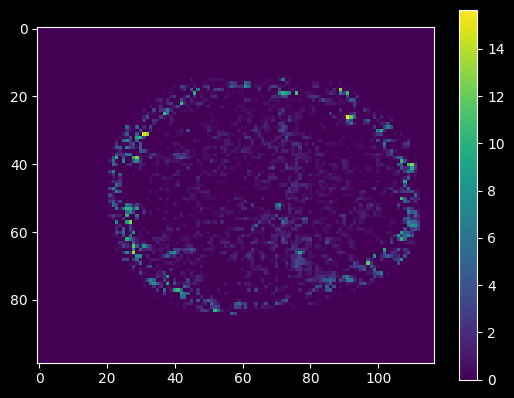

In [55]:
new_beta_mni = resample_img(
    img=new_img,        # Your subject-native beta map
    target_affine=mni_affine,        # MNI template affine
    target_shape=mni_shape,          # MNI template shape (optional but recommended)
    interpolation='continuous',      # Cubic interpolation (matches NSD's method)
    fill_value=0,                    # Set non-brain voxels to 0 (like NSD)
    clip=True                        # Clip values outside original range
)

new_d = new_beta_mni.get_fdata(dtype=np.float32)
plt.imshow(new_d[:, :, 95//2], vmin=0)
plt.colorbar()

In [57]:
(new_d - d).sum()

np.float32(-1.7721513e-05)